In [2]:
#!pip install pandas numpy matplotlib
#!pip install seaborn
#!pip install os

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

# 1. Thiết lập đường dẫn (dấu '.' nếu file nằm cùng thư mục với code)
path = '.' 

# 2. Lấy danh sách tất cả file kết thúc bằng .csv
files = [f for f in os.listdir(path) if f.endswith('.csv')]

# 3. Đọc tất cả vào một Dictionary
# Key là tên file (bỏ đuôi .csv), Value là nội dung bảng (DataFrame)
data = {f[:-4]: pd.read_csv(os.path.join(path, f)) for f in files}

# 4. Kiểm tra các bảng đã đọc được
print("Các bảng đã load thành công:", data.keys())

Các bảng đã load thành công: dict_keys(['customers', 'geography', 'inventory', 'orders', 'order_items', 'payments', 'products', 'promotions', 'returns', 'reviews', 'sales', 'sample_submission', 'shipments', 'web_traffic'])


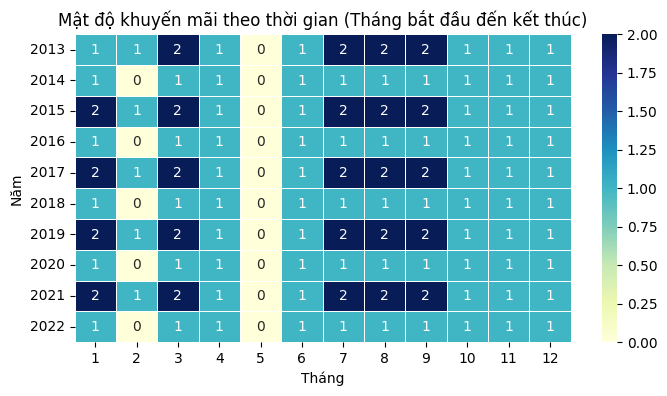

In [4]:
# 1. Đọc dữ liệu
df_promos = pd.read_csv("promotions.csv")

# 2. Chuyển đổi cột ngày tháng về đúng định dạng datetime
df_promos['start_date'] = pd.to_datetime(df_promos['start_date'])
df_promos['end_date'] = pd.to_datetime(df_promos['end_date'])

# 3. Tạo danh sách các tháng mà mỗi khuyến mãi trải qua
promo_months = []

for index, row in df_promos.iterrows():
    # Tạo dải thời gian từ tháng bắt đầu đến tháng kết thúc (tần suất tháng 'MS')
    date_range = pd.date_range(start=row['start_date'].replace(day=1), 
                               end=row['end_date'], 
                               freq='MS')
    for date in date_range:
        promo_months.append({'Year': date.year, 'Month': date.month})

# 4. Tạo DataFrame mới từ danh sách đã trải phẳng
df_heatmap = pd.DataFrame(promo_months)

# 5. Tạo bảng Pivot để đếm số lượng khuyến mãi mỗi tháng
pivot_table = df_heatmap.pivot_table(index='Year', 
                                     columns='Month', 
                                     aggfunc='size', 
                                     fill_value=0)

# 6. Đảm bảo đủ 12 tháng trên trục X (từ tháng 1 đến 12)
for m in range(1, 13):
    if m not in pivot_table.columns:
        pivot_table[m] = 0
pivot_table = pivot_table.reindex(columns=sorted(pivot_table.columns))

# 7. Vẽ biểu đồ
plt.figure(figsize=(8, 4))
sns.heatmap(pivot_table, annot=True, fmt="d", cmap="YlGnBu", linewidths=.5)
plt.title('Mật độ khuyến mãi theo thời gian (Tháng bắt đầu đến kết thúc)')
plt.xlabel('Tháng')
plt.ylabel('Năm')
plt.show()

In [ ]:
# ============================================================
# PHÂN TÍCH TOÀN DIỆN: TẠI SAO PROMO KHÔNG HIỆU QUẢ?

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# --- Load tất cả bảng ---
order_items = pd.read_csv("order_items.csv")
orders      = pd.read_csv("orders.csv")
products    = pd.read_csv("products.csv")
promotions  = pd.read_csv("promotions.csv")
returns     = pd.read_csv("returns.csv")
reviews     = pd.read_csv("reviews.csv")
web_traffic = pd.read_csv("web_traffic.csv")
inventory   = pd.read_csv("inventory.csv")

# Chuẩn hóa tên cột
for d in [order_items, orders, products, promotions,
          returns, reviews, web_traffic, inventory]:
    d.columns = d.columns.str.lower().str.strip().str.replace(" ", "_")

print("=== DATA LOADED ===")
for name, d in [("order_items", order_items), ("orders", orders),
                ("products", products), ("promotions", promotions),
                ("returns", returns), ("reviews", reviews),
                ("web_traffic", web_traffic), ("inventory", inventory)]:
    print(f"  {name:12s}: {d.shape}  | cols: {d.columns.tolist()}")

# --- Base calculations (dùng chung cho tất cả GT) ---
qty   = order_items["quantity"].fillna(1)
price = order_items["unit_price"].fillna(0)
disc  = order_items["discount_amount"].fillna(0) if "discount_amount" in order_items.columns else pd.Series(0, index=order_items.index)
cogs_map = products.set_index("product_id")["cogs"].to_dict()

order_items["net_revenue"]  = qty * price - disc
order_items["cogs_val"]     = qty * order_items["product_id"].map(cogs_map).fillna(0)
order_items["gross_profit"] = order_items["net_revenue"] - order_items["cogs_val"]
order_items["discount_pct"] = (disc / (qty * price).replace(0, np.nan) * 100).round(2)

# Gắn nhãn promo
order_items["has_promo1"] = (
    order_items["promo_id"].notna() &
    (~order_items["promo_id"].astype(str).str.strip().isin(["", "0", "nan"]))
)
order_items["has_promo2"] = (
    order_items["promo_id_2"].notna() &
    (~order_items["promo_id_2"].astype(str).str.strip().isin(["", "0", "nan"]))
) if "promo_id_2" in order_items.columns else False

order_items["is_promo"]    = order_items["has_promo1"] | order_items["has_promo2"]
order_items["is_stacked"]  = order_items["has_promo1"] & order_items["has_promo2"]
order_items["promo_label"] = order_items["is_promo"].map({True: "Co Promo", False: "Khong Promo"})

print(f"\nTong don hang     : {len(order_items):,}")
print(f"Don co promo      : {order_items['is_promo'].sum():,} ({order_items['is_promo'].mean()*100:.1f}%)")
print(f"Don stack 2 promo : {order_items['is_stacked'].sum():,} ({order_items['is_stacked'].mean()*100:.1f}%)")
print("\n>>> Setup hoan tat! Chay cac cell tiep theo.")


=== DATA LOADED ===
  order_items : (714669, 7)  | cols: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
  orders      : (646945, 8)  | cols: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
  products    : (2412, 8)  | cols: ['product_id', 'product_name', 'category', 'segment', 'size', 'color', 'price', 'cogs']
  promotions  : (50, 10)  | cols: ['promo_id', 'promo_name', 'promo_type', 'discount_value', 'start_date', 'end_date', 'applicable_category', 'promo_channel', 'stackable_flag', 'min_order_value']
  returns     : (39939, 7)  | cols: ['return_id', 'order_id', 'product_id', 'return_date', 'return_reason', 'return_quantity', 'refund_amount']
  reviews     : (113551, 7)  | cols: ['review_id', 'order_id', 'product_id', 'customer_id', 'review_date', 'rating', 'review_title']
  web_traffic : (3652, 7)  | cols: ['date', 'sessions', 'unique_visitors', 'page_views', 'bounce_r

=== PHÂN TÍCH STACK PROMO ===
               n_orders  avg_discount_pct  avg_gross_profit  total_gross_profit  avg_quantity  pct_negative_gp  pct_of_orders
promo_group                                                                                                                  
Không Promo      438353              0.00           5007.41        2.195015e+09          4.50             0.18           61.3
Single Promo     276110             14.31          -2454.50       -6.777132e+08          4.50            68.97           38.6
Stack 2 Promo       206             10.32            566.05        1.166055e+05          4.05            55.83            0.0

=== STACKABLE FLAG TRONG PROMOTIONS ===
stackable_flag
0    38
1    12
Name: count, dtype: int64

Đơn hàng vi phạm stackable_flag: 206 / 206


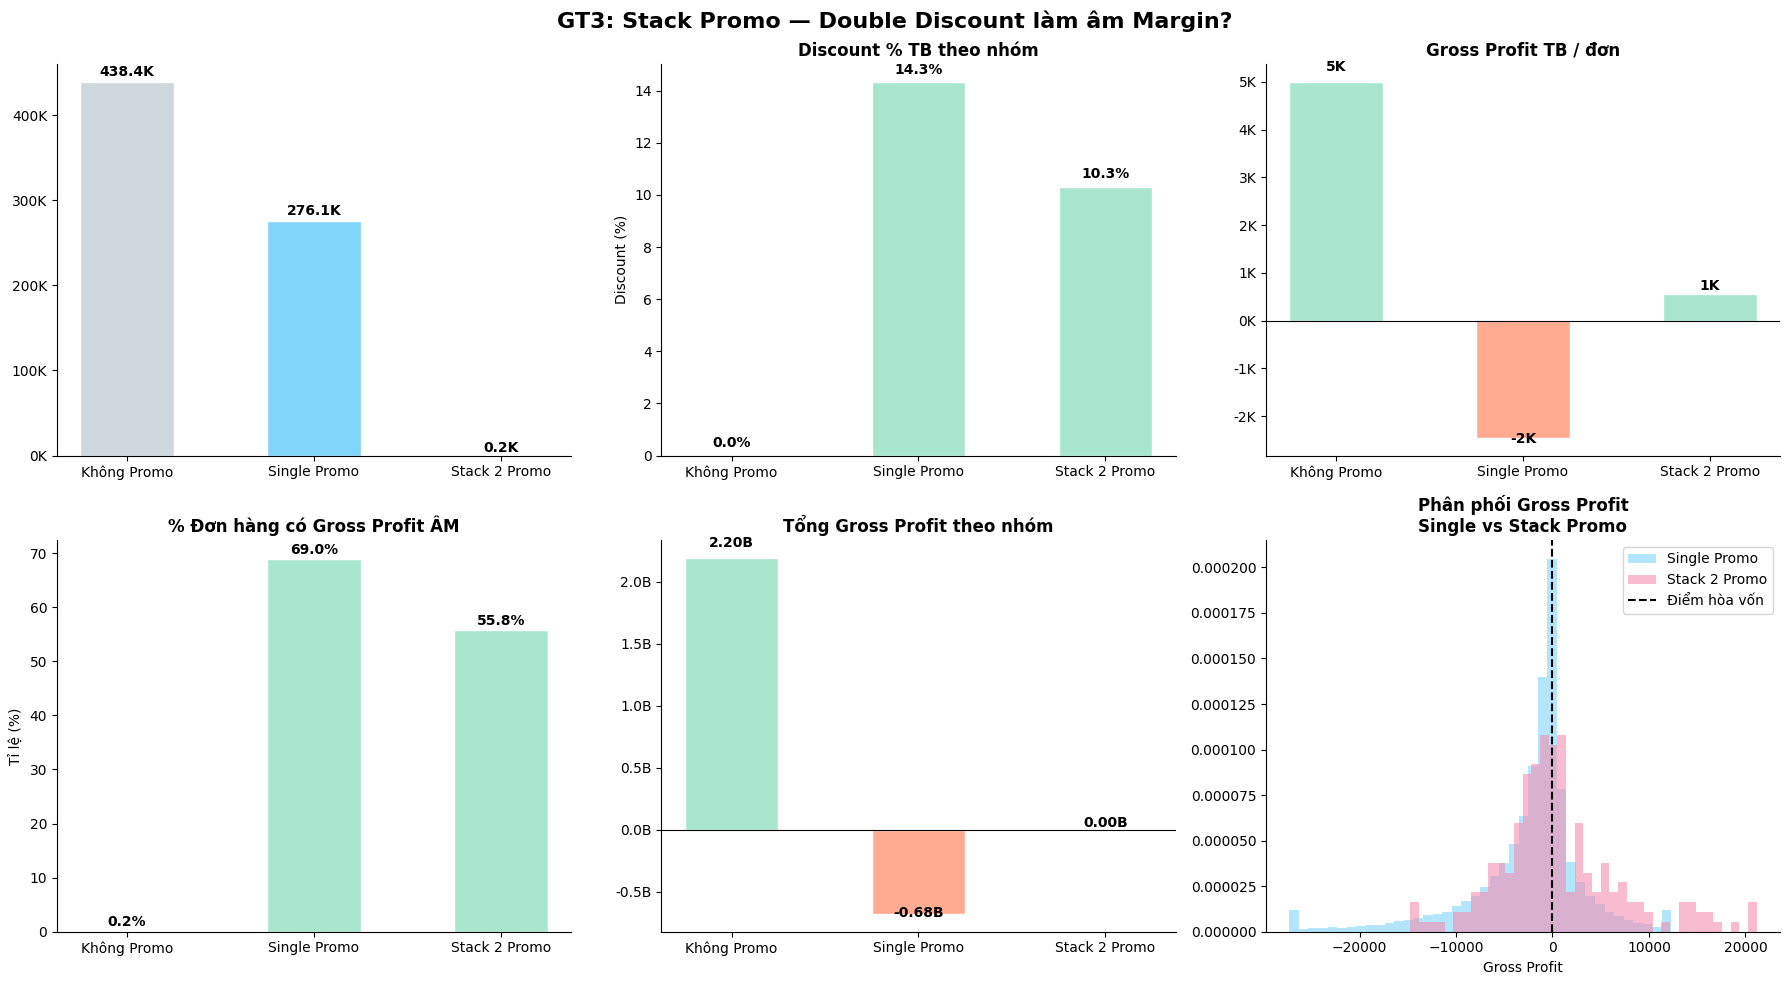


=== KẾT LUẬN GT3 ===
Discount TB - Stack: 10.3% | Single: 14.3%
GP TB       - Stack: 566 | Single: -2,454
% GP âm     - Stack: 55.8%
>>> GT3 KHÔNG RÕ: Stack promo không gây ra chênh lệch lớn.


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Cấu hình màu sắc Pastel ---
# Màu chủ đạo: Xanh lá pastel (#A8E6CF)
# Palette cho nhóm: Không Promo (Xám nhạt), Single (Xanh dương pastel), Stack (Đỏ/Hồng pastel)
colors_pastel = ["#CFD8DC", "#81D4FA", "#F48FB1"] 
green_pastel = "#A8E6CF"

# Phân nhóm đơn hàng
order_items["promo_group"] = "Không Promo"
order_items.loc[order_items["has_promo1"] & ~order_items["has_promo2"], "promo_group"] = "Single Promo"
order_items.loc[order_items["is_stacked"], "promo_group"] = "Stack 2 Promo"

group_stats = order_items.groupby("promo_group").agg(
    n_orders         = ("quantity",      "count"),
    avg_discount_pct = ("discount_pct",  "mean"),
    avg_gross_profit = ("gross_profit",  "mean"),
    total_gross_profit = ("gross_profit","sum"),
    avg_quantity     = ("quantity",      "mean"),
    pct_negative_gp  = ("gross_profit",  lambda x: (x < 0).mean() * 100),
).round(2)
group_stats["pct_of_orders"] = (group_stats["n_orders"] / group_stats["n_orders"].sum() * 100).round(1)

print("=== PHÂN TÍCH STACK PROMO ===")
print(group_stats.to_string())

# Kiểm tra stackable_flag
if "stackable_flag" in promotions.columns:
    print("\n=== STACKABLE FLAG TRONG PROMOTIONS ===")
    print(promotions["stackable_flag"].value_counts())
    non_stackable = promotions[promotions["stackable_flag"] == 0]["promo_id"].tolist()
    stacked_orders = order_items[order_items["is_stacked"]]
    violation = stacked_orders[
        stacked_orders["promo_id"].isin(non_stackable) |
        stacked_orders["promo_id_2"].isin(non_stackable)
    ]
    print(f"\nĐơn hàng vi phạm stackable_flag: {len(violation):,} / {len(stacked_orders):,}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("GT3: Stack Promo — Double Discount làm âm Margin?", fontsize=16, fontweight="bold")
group_order = ["Không Promo", "Single Promo", "Stack 2 Promo"]

# --- 3a. Số đơn hàng theo nhóm (Sử dụng 3 màu pastel) ---
ax = axes[0, 0]
n_vals = [group_stats.loc[g, "n_orders"] if g in group_stats.index else 0 for g in group_order]
bars = ax.bar(group_order, n_vals, color=colors_pastel, edgecolor="white", width=0.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, v in zip(bars, n_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
            f"{v/1e3:.1f}K", ha="center", va="bottom", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- 3b. Discount % trung bình (Sử dụng 1 màu xanh lá pastel) ---
ax = axes[0, 1]
d_vals = [group_stats.loc[g, "avg_discount_pct"] if g in group_stats.index else 0 for g in group_order]
bars = ax.bar(group_order, d_vals, color=green_pastel, edgecolor="white", width=0.5)
ax.set_title("Discount % TB theo nhóm", fontweight="bold")
ax.set_ylabel("Discount (%)")
for bar, v in zip(bars, d_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- 3c. Gross profit TB (Xanh pastel cho dương, Đỏ pastel cho âm) ---
ax = axes[0, 2]
gp_vals = [group_stats.loc[g, "avg_gross_profit"] if g in group_stats.index else 0 for g in group_order]
bar_colors_gp = [green_pastel if v >= 0 else "#FFAB91" for v in gp_vals]
bars = ax.bar(group_order, gp_vals, color=bar_colors_gp, edgecolor="white", width=0.5)
ax.set_title("Gross Profit TB / đơn", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))
for bar, v in zip(bars, gp_vals):
    ax.text(bar.get_x() + bar.get_width()/2,
            v * 1.03 if v >= 0 else v * 1.07,
            f"{v/1e3:.0f}K", ha="center", va="bottom", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- 3d. % đơn có gross profit âm (Sử dụng 1 màu xanh lá pastel) ---
ax = axes[1, 0]
neg_vals = [group_stats.loc[g, "pct_negative_gp"] if g in group_stats.index else 0 for g in group_order]
bars = ax.bar(group_order, neg_vals, color=green_pastel, edgecolor="white", width=0.5)
ax.set_title("% Đơn hàng có Gross Profit ÂM", fontweight="bold")
ax.set_ylabel("Tỉ lệ (%)")
for bar, v in zip(bars, neg_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{v:.1f}%", ha="center", va="bottom", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- 3e. Tổng gross profit (Xanh pastel cho dương, Đỏ pastel cho âm) ---
ax = axes[1, 1]
total_gp = [group_stats.loc[g, "total_gross_profit"] if g in group_stats.index else 0 for g in group_order]
bar_colors_tgp = [green_pastel if v >= 0 else "#FFAB91" for v in total_gp]
bars = ax.bar(group_order, total_gp, color=bar_colors_tgp, edgecolor="white", width=0.5)
ax.set_title("Tổng Gross Profit theo nhóm", fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}B"))
for bar, v in zip(bars, total_gp):
    ax.text(bar.get_x() + bar.get_width()/2,
            v * 1.03 if v >= 0 else v * 1.07,
            f"{v/1e9:.2f}B", ha="center", va="bottom", fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --- 3f. Phân phối gross profit: Single vs Stack (Màu Pastel) ---
ax = axes[1, 2]
for grp, color in zip(["Single Promo", "Stack 2 Promo"], ["#81D4FA", "#F48FB1"]):
    sub = order_items[order_items["promo_group"] == grp]["gross_profit"].dropna()
    sub_clipped = sub.clip(sub.quantile(0.01), sub.quantile(0.99))
    ax.hist(sub_clipped, bins=40, alpha=0.6, color=color, label=grp, density=True)
ax.axvline(0, color="black", linewidth=1.5, linestyle="--", label="Điểm hòa vốn")
ax.set_title("Phân phối Gross Profit\nSingle vs Stack Promo", fontweight="bold")
ax.set_xlabel("Gross Profit")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== KẾT LUẬN GT3 ===")
if "Stack 2 Promo" in group_stats.index and "Single Promo" in group_stats.index:
    stack_disc  = group_stats.loc["Stack 2 Promo", "avg_discount_pct"]
    single_disc = group_stats.loc["Single Promo",  "avg_discount_pct"]
    stack_gp    = group_stats.loc["Stack 2 Promo", "avg_gross_profit"]
    single_gp   = group_stats.loc["Single Promo",  "avg_gross_profit"]
    stack_neg   = group_stats.loc["Stack 2 Promo", "pct_negative_gp"]
    print(f"Discount TB - Stack: {stack_disc:.1f}% | Single: {single_disc:.1f}%")
    print(f"GP TB       - Stack: {stack_gp:,.0f} | Single: {single_gp:,.0f}")
    print(f"% GP âm     - Stack: {stack_neg:.1f}%")
    if stack_disc > single_disc * 1.3 or stack_gp < single_gp * 0.5:
        print(">>> GT3 CÓ KHẢ NĂNG ĐÚNG: Stack promo làm discount tăng mạnh và giảm GP!")
    else:
        print(">>> GT3 KHÔNG RÕ: Stack promo không gây ra chênh lệch lớn.")

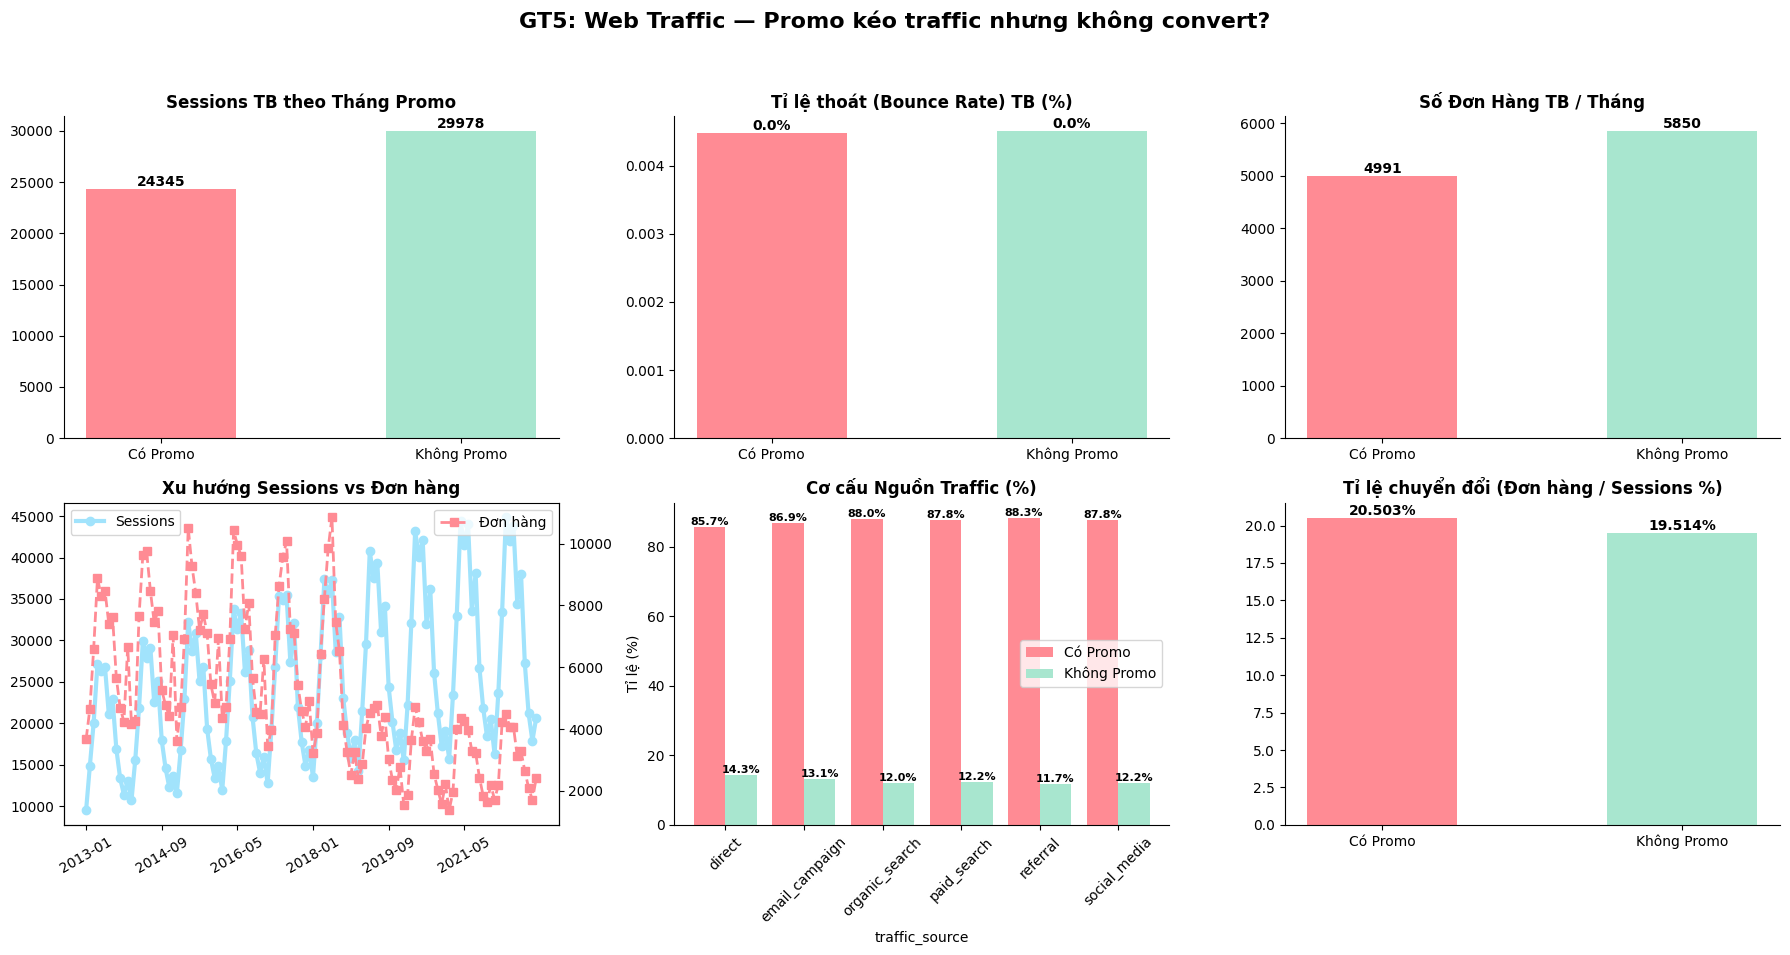

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# --- 1. Cấu hình màu sắc Pastel nguyên bản ---
green_pastel = "#A8E6CF"
red_pastel = "#FF8B94"
blue_pastel = "#A1E3FC"
# Gán màu theo nhóm để thống nhất
color_map = {"Có Promo": red_pastel, "Không Promo": green_pastel}

# --- Tiền xử lý dữ liệu (Giữ nguyên logic của bạn) ---
web_traffic["date"] = pd.to_datetime(web_traffic["date"], errors="coerce")
web_traffic["month"] = web_traffic["date"].dt.to_period("M")

for col in ["sessions", "bounce_rate", "n_orders"]:
    if col in web_traffic.columns:
        web_traffic[col] = pd.to_numeric(web_traffic[col], errors='coerce')

promo_months_set = set()
for _, row in promotions.iterrows():
    if pd.notna(row["start_date"]) and pd.notna(row["end_date"]):
        dr = pd.date_range(start=pd.to_datetime(row["start_date"]).replace(day=1),
                           end=pd.to_datetime(row["end_date"]), freq="MS")
        for d in dr:
            promo_months_set.add(d.to_period("M"))

web_traffic["has_promo_month"] = web_traffic["month"].isin(promo_months_set)
web_traffic["promo_label"] = web_traffic["has_promo_month"].map({True: "Có Promo", False: "Không Promo"})

orders["order_date"] = pd.to_datetime(orders["order_date"], errors="coerce")
orders["month"] = orders["order_date"].dt.to_period("M")
monthly_orders = orders.groupby("month").agg(n_orders=("order_id", "count")).reset_index()
monthly_orders["has_promo_month"] = monthly_orders["month"].isin(promo_months_set)
monthly_orders["promo_label"] = monthly_orders["has_promo_month"].map({True: "Có Promo", False: "Không Promo"})

# --- Vẽ biểu đồ ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plt.subplots_adjust(top=0.9, hspace=0.4) 
fig.suptitle("GT5: Web Traffic — Promo kéo traffic nhưng không convert?", fontsize=16, fontweight="bold")

# Hàm hỗ trợ thêm nhãn dữ liệu
def add_labels(ax, bars, is_pct=False, precision=0):
    for bar in bars:
        height = bar.get_height()
        label = f"{height:.{precision}f}" + ("%" if is_pct else "")
        ax.text(bar.get_x() + bar.get_width()/2, height, label, 
                ha="center", va="bottom", fontweight="bold", fontsize=10)

# --- 5a. Sessions TB ---
ax = axes[0, 0]
if "sessions" in web_traffic.columns:
    sess = web_traffic.groupby("promo_label")["sessions"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
    bars = ax.bar(sess.index, sess.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Sessions TB theo Tháng Promo", fontweight="bold")
    add_labels(ax, bars)
ax.spines[["top", "right"]].set_visible(False)

# --- 5b. Bounce rate TB (%) ---
ax = axes[0, 1]
if "bounce_rate" in web_traffic.columns:
    bounce = web_traffic.groupby("promo_label")["bounce_rate"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
    bars = ax.bar(bounce.index, bounce.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Tỉ lệ thoát (Bounce Rate) TB (%)", fontweight="bold")
    add_labels(ax, bars, is_pct=True, precision=1)
ax.spines[["top", "right"]].set_visible(False)

# --- 5c. Đơn hàng TB / Tháng ---
ax = axes[0, 2]
orders_avg = monthly_orders.groupby("promo_label")["n_orders"].mean().reindex(["Có Promo", "Không Promo"]).fillna(0)
bars = ax.bar(orders_avg.index, orders_avg.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
ax.set_title("Số Đơn Hàng TB / Tháng", fontweight="bold")
add_labels(ax, bars)
ax.spines[["top", "right"]].set_visible(False)

# --- 5d. Xu hướng Sessions vs Đơn hàng ---
ax = axes[1, 0]
m_sess = web_traffic.groupby("month")["sessions"].mean().reset_index()
m_sess["month_str"] = m_sess["month"].astype(str)
m_ord = monthly_orders[["month", "n_orders"]].copy()
m_ord["month_str"] = m_ord["month"].astype(str)
merged = pd.merge(m_sess, m_ord, on="month_str", how="inner")

if not merged.empty:
    ax2 = ax.twinx()
    ax.plot(merged["month_str"], merged["sessions"], color=blue_pastel, marker='o', label="Sessions", linewidth=3)
    ax2.plot(merged["month_str"], merged["n_orders"], color=red_pastel, marker='s', label="Đơn hàng", linestyle="--", linewidth=2)
    ax.set_title("Xu hướng Sessions vs Đơn hàng", fontweight="bold")
    ax.set_xticks(range(0, len(merged), max(1, len(merged)//6)))
    ax.tick_params(axis='x', rotation=30)
    ax.legend(loc="upper left")
    ax2.legend(loc="upper right")
ax.spines["top"].set_visible(False)

# --- 5e. Cơ cấu Nguồn Traffic (%) ---
ax = axes[1, 1]
if "traffic_source" in web_traffic.columns:
    src = web_traffic.groupby(["traffic_source", "promo_label"]).size().unstack(fill_value=0)
    src_pct = src.div(src.sum(axis=1), axis=0) * 100
    # Đảm bảo thứ tự hiển thị của Legend đồng nhất
    src_pct = src_pct[["Có Promo", "Không Promo"]]
    
    src_pct.plot(kind="bar", ax=ax, color=[red_pastel, green_pastel], edgecolor="none", width=0.8)
    ax.set_title("Cơ cấu Nguồn Traffic (%)", fontweight="bold")
    ax.set_ylabel("Tỉ lệ (%)")
    ax.tick_params(axis='x', rotation=45)
    
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f"{p.get_height():.1f}%", 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.legend(title="")
ax.spines[["top", "right"]].set_visible(False)

# --- 5f. Tỉ lệ chuyển đổi (%) ---
ax = axes[1, 2]
if "sessions" in web_traffic.columns:
    # Lấy sess đã tính ở trên (đúng thứ tự nhãn)
    cr = (orders_avg / sess * 100).fillna(0)
    bars = ax.bar(cr.index, cr.values, color=[red_pastel, green_pastel], width=0.5, edgecolor="none")
    ax.set_title("Tỉ lệ chuyển đổi (Đơn hàng / Sessions %)", fontweight="bold")
    # Tỉ lệ chuyển đổi thường nhỏ nên dùng 3 chữ số thập phân
    add_labels(ax, bars, is_pct=True, precision=3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()